In [55]:
import os
import matplotlib.pyplot as plt

import rocqiomics as rq
from rocqiomics.transforms import N4ITKBiasFieldCorrection

import SimpleITK as sitk

from monai.transforms import (
    Compose,
    ScaleIntensityd,
    NormalizeIntensityd,
    Spacingd,
    RandAffined,
    RandGaussianNoised,
)

[{'case_id': 'RGS021425_ph1',
  'image': 'c:\\Users\\ri54995\\OneDrive - Roswell Park Comprehensive Cancer Center\\Projects\\Radiomics Pipeline\\rocqiomics\\tutorial\\test_data\\Images\\d1_T2_RGS021425_ph1.nrrd',
  'mask': 'c:\\Users\\ri54995\\OneDrive - Roswell Park Comprehensive Cancer Center\\Projects\\Radiomics Pipeline\\rocqiomics\\tutorial\\test_data\\Masks\\d1_T2_RGS021425_ph1.seg.nrrd',
  'metadata': {'mask_name': 'Snickers', 'modality': 'T2', 'timepoint': 'd1'}}]

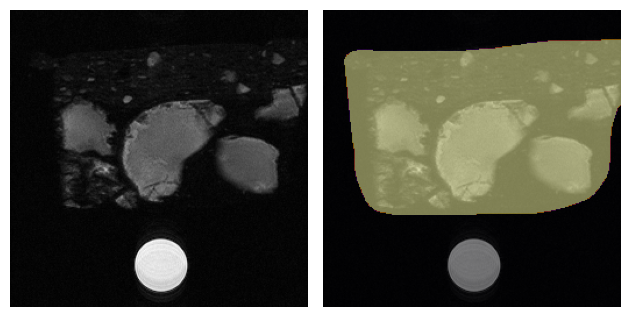

In [56]:
# Only image and mask keywords are required. Use case_id and metadata to keep better track of data in pandas dataframes and saved results.
train_data_dicts = [
    {
        'case_id' : f'RGS021425_ph{i}',
        'image' : os.path.join(os.getcwd(), 'test_data', 'Images', f'{tp}_T2_RGS021425_ph{i}.nrrd'),
        'mask' : os.path.join(os.getcwd(), 'test_data', 'Masks', f'{tp}_T2_RGS021425_ph{i}.seg.nrrd'),
        'metadata' : {
            'mask_name' : 'Snickers',
            'modality' : 'T2',
            'timepoint' : tp 
        }
    }
for i in range(1,4) for tp in ['d1']]

test_data_dicts = [
    {
        'case_id' : f'RGS021425_ph{i}',
        'image' : os.path.join(os.getcwd(), 'test_data', 'Images', f'{tp}_T2_RGS021425_ph{i}.nrrd'),
        'mask' : os.path.join(os.getcwd(), 'test_data', 'Masks', f'{tp}_T2_RGS021425_ph{i}.seg.nrrd'),
        'metadata' : {
            'mask_name' : 'Snickers',
            'modality' : 'T2',
            'timepoint' : tp 
        }
    }
for i in range(1,4) for tp in ['d5']]

display(train_data_dicts[0:1])
rq.utils.plot_data_dict(train_data_dicts[0], rows=1)

In [65]:
# Use Compose to apply the standard (intensity intensity normalization, re-spacing, etc.) preprocessing transforms to all loaded images/masks
preprocessing_transform = Compose([
        N4ITKBiasFieldCorrection(image_key='image', mask_key='mask', max_iterations=20),
        NormalizeIntensityd(keys=['image']), # Standardize image intensity (subtract mean and divide by standard dev)
        Spacingd(keys=['image', 'mask'], pixdim=(0.25, 0.25, 1.0), mode=[3, 'nearest']), # Resample image and mask to specified voxel size
    ])

features = ['Mean', 'Busyness', 'Autocorrelation']
VECTOR_SAVE_DIRPATH = r"C:\Users\ri54995\Downloads\VectorImages"

radhab = rq.RadiomicsHabitatGenerator(
    preprocessing=preprocessing_transform,
    augmentations=None,
    bin_width=25.0,
    features=features,
    algorithm='kmeans',
    n_clusters=5,
    batch_size=25,
    save_vector_dirpath=VECTOR_SAVE_DIRPATH,
)

train_predictions, train_res_ddicts = radhab.fit_predict(train_data_dicts)
test_predictions, test_res_ddicts = radhab.predict(test_data_dicts)

rocqiomics INFO:	 Radiomics Habitat Generation Pipeline Initialized.
rocqiomics INFO:	 Validating images and masks.


rocqiomics INFO:	 Extraction Pipeline Initialized | Engine: pyradiomics | Cases: 3 | Excluded cases: 0
rocqiomics INFO:	 Case 0/2 done in 5.91s	case_id: RGS021425_ph1	mask_name: Snickers	modality: T2	timepoint: d1	augmentation: 0	image_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Center\Projects\Radiomics Pipeline\rocqiomics\tutorial\test_data\Images\d1_T2_RGS021425_ph1.nrrd	mask_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Center\Projects\Radiomics Pipeline\rocqiomics\tutorial\test_data\Masks\d1_T2_RGS021425_ph1.seg.nrrd
rocqiomics INFO:	 Case 1/2 done in 5.95s	case_id: RGS021425_ph2	mask_name: Snickers	modality: T2	timepoint: d1	augmentation: 0	image_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Center\Projects\Radiomics Pipeline\rocqiomics\tutorial\test_data\Images\d1_T2_RGS021425_ph2.nrrd	mask_path: c:\Users\ri54995\OneDrive - Roswell Park Comprehensive Cancer Center\Projects\Radiomics Pipeline\rocqiomics\tutorial\

In [66]:
train_res_ddicts[0]

{'image': 'C:\\Users\\ri54995\\Downloads\\VectorImages\\RGS021425_ph1_Snickers_T2_d1_0.nrrd',
 'mask': 'c:\\Users\\ri54995\\OneDrive - Roswell Park Comprehensive Cancer Center\\Projects\\Radiomics Pipeline\\rocqiomics\\tutorial\\test_data\\Masks\\d1_T2_RGS021425_ph1.seg.nrrd',
 'metadata': {'case_id': 'RGS021425_ph1',
  'mask_name': 'Snickers',
  'modality': 'T2',
  'timepoint': 'd1',
  'augmentation': 0,
  'image_path': 'c:\\Users\\ri54995\\OneDrive - Roswell Park Comprehensive Cancer Center\\Projects\\Radiomics Pipeline\\rocqiomics\\tutorial\\test_data\\Images\\d1_T2_RGS021425_ph1.nrrd',
  'mask_path': 'c:\\Users\\ri54995\\OneDrive - Roswell Park Comprehensive Cancer Center\\Projects\\Radiomics Pipeline\\rocqiomics\\tutorial\\test_data\\Masks\\d1_T2_RGS021425_ph1.seg.nrrd'},
 'case_id': 'RGS021425_ph1',
 'feature_names': ['original_Autocorrelation',
  'original_Busyness',
  'original_Mean']}

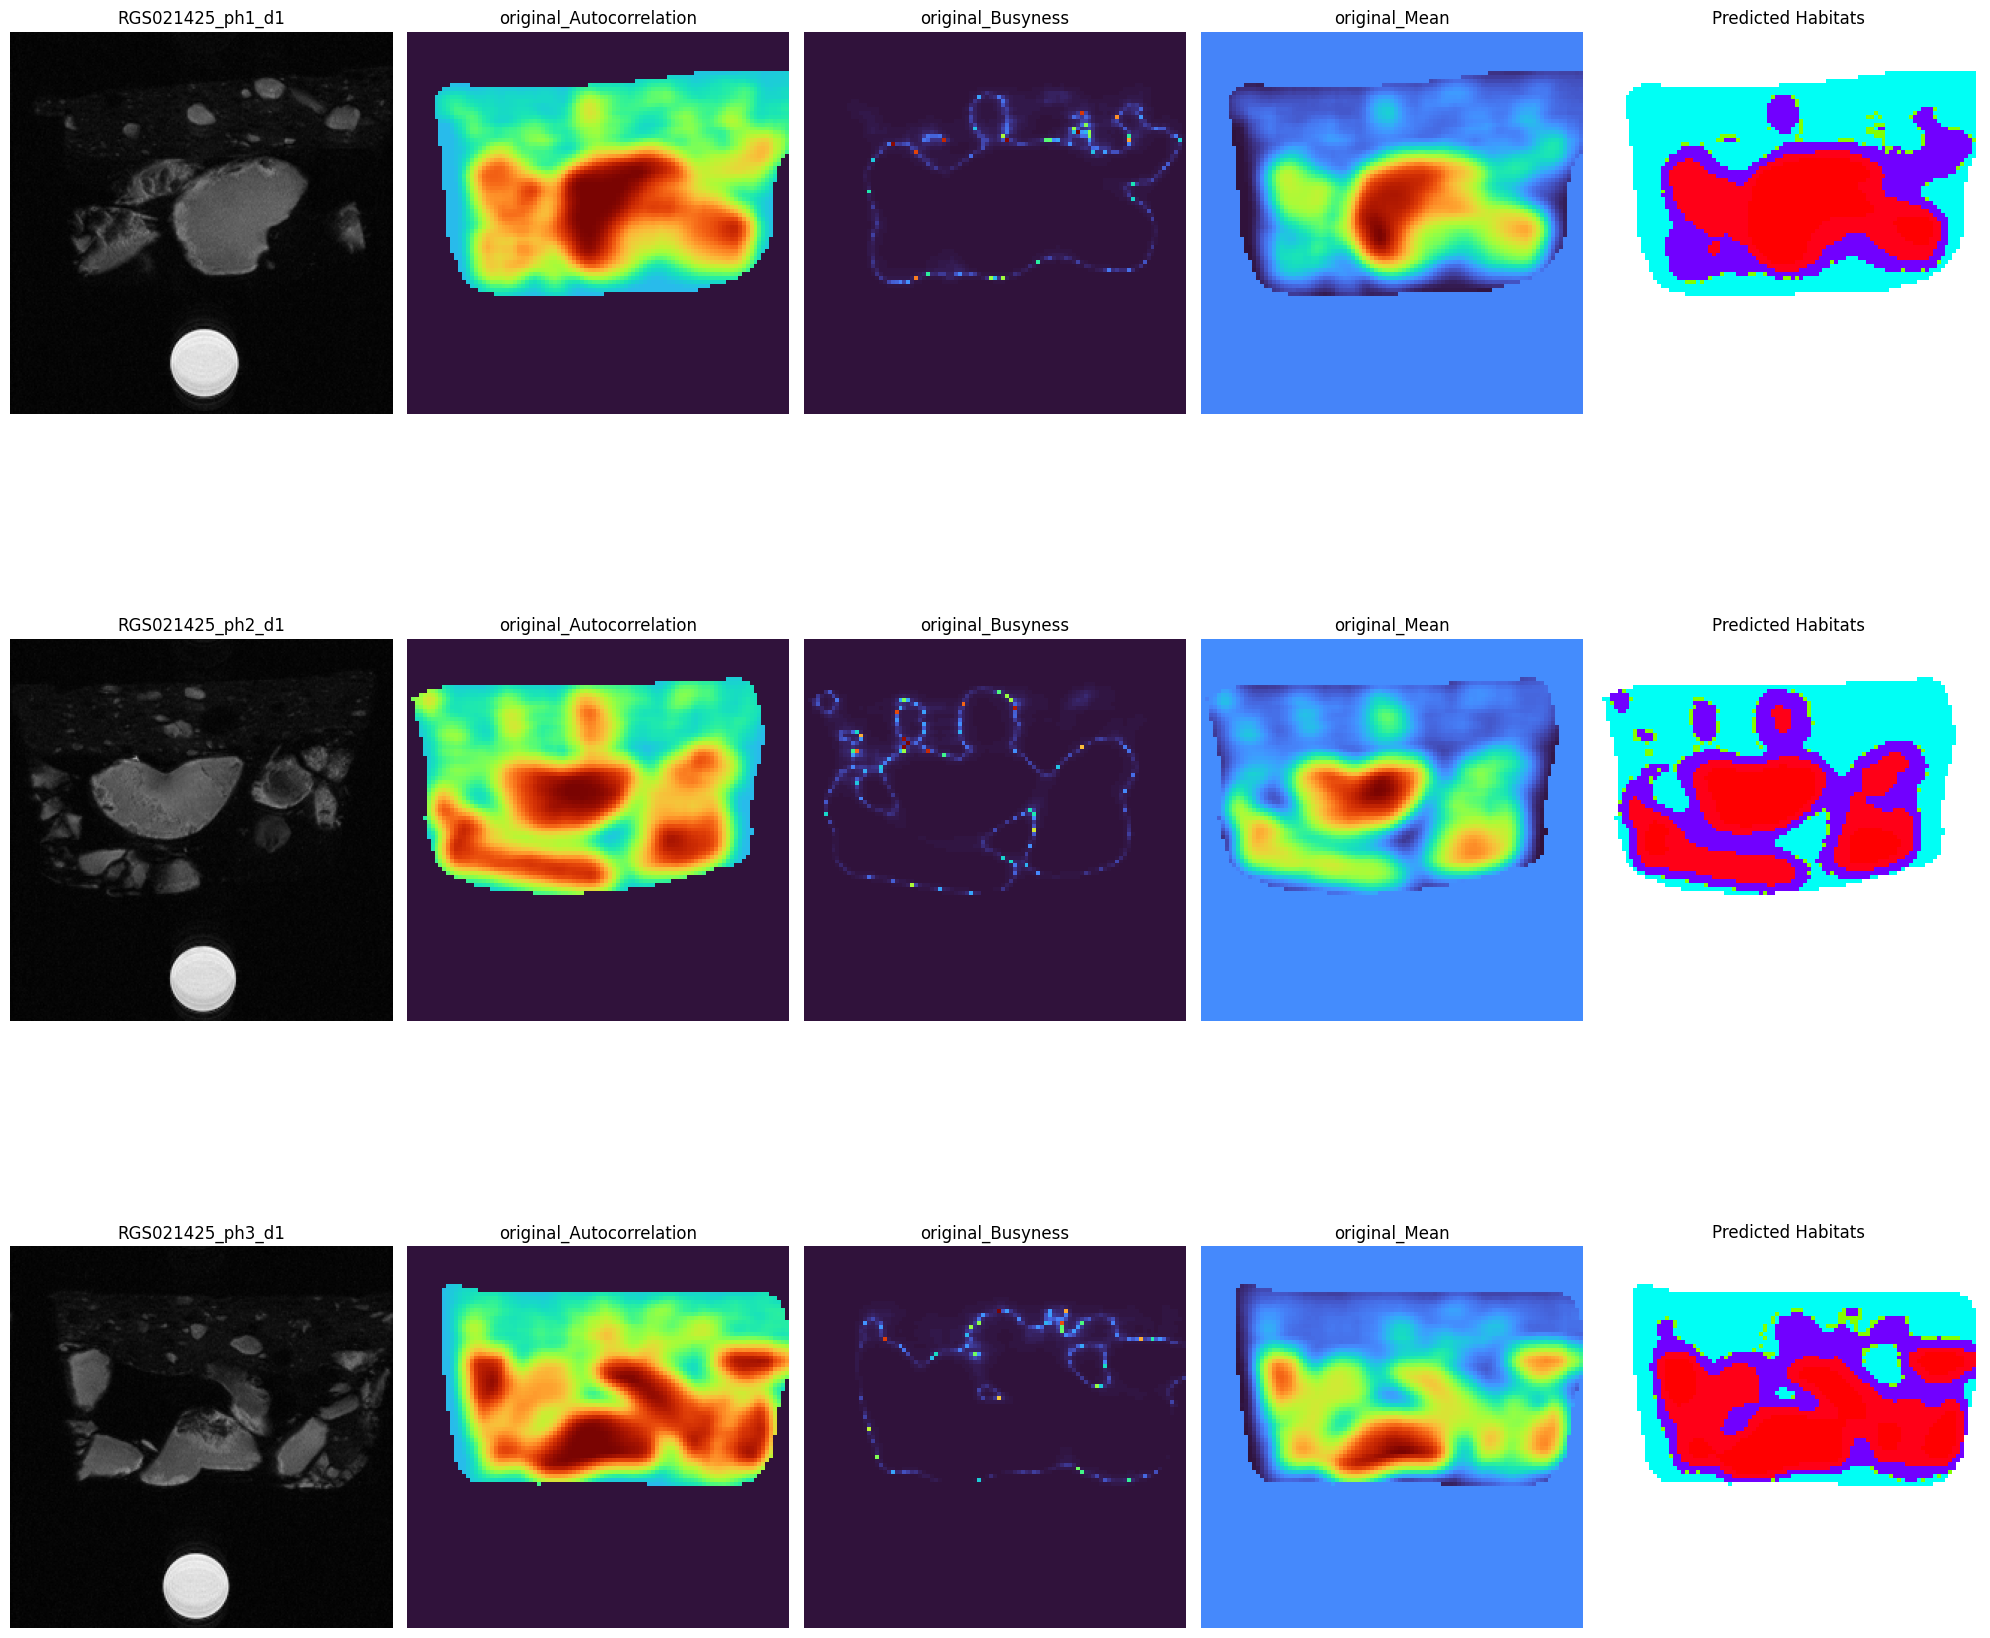

In [67]:
fig, ax = plt.subplots(len(train_data_dicts), len(features) + 2, figsize=(20,20))
sl = 15

for i, dd in enumerate(train_res_ddicts):
    img = sitk.ReadImage(dd['metadata']['image_path'])
    img_arr = sitk.GetArrayFromImage(img)

    img_maps = sitk.ReadImage(dd['image'])
    maps_arr = sitk.GetArrayFromImage(img_maps)
    num_maps = len(dd['feature_names'])

    ax[i,0].imshow(img_arr[sl,:,:], cmap='gray')
    ax[i,0].set_title(dd['case_id'] + '_' + dd['metadata']['timepoint'])

    for k in range(num_maps):
        ax[i,k+1].imshow(maps_arr[sl,:,:,k], cmap='turbo')
        ax[i,k+1].set_title(dd['feature_names'][k])

    ax[i,num_maps+1].imshow(train_predictions[i][sl,:,:], cmap='hsv')
    ax[i,num_maps+1].set_title('Predicted Habitats')
    
for a in ax.flatten():
    a.axis('off')
plt.tight_layout()
        

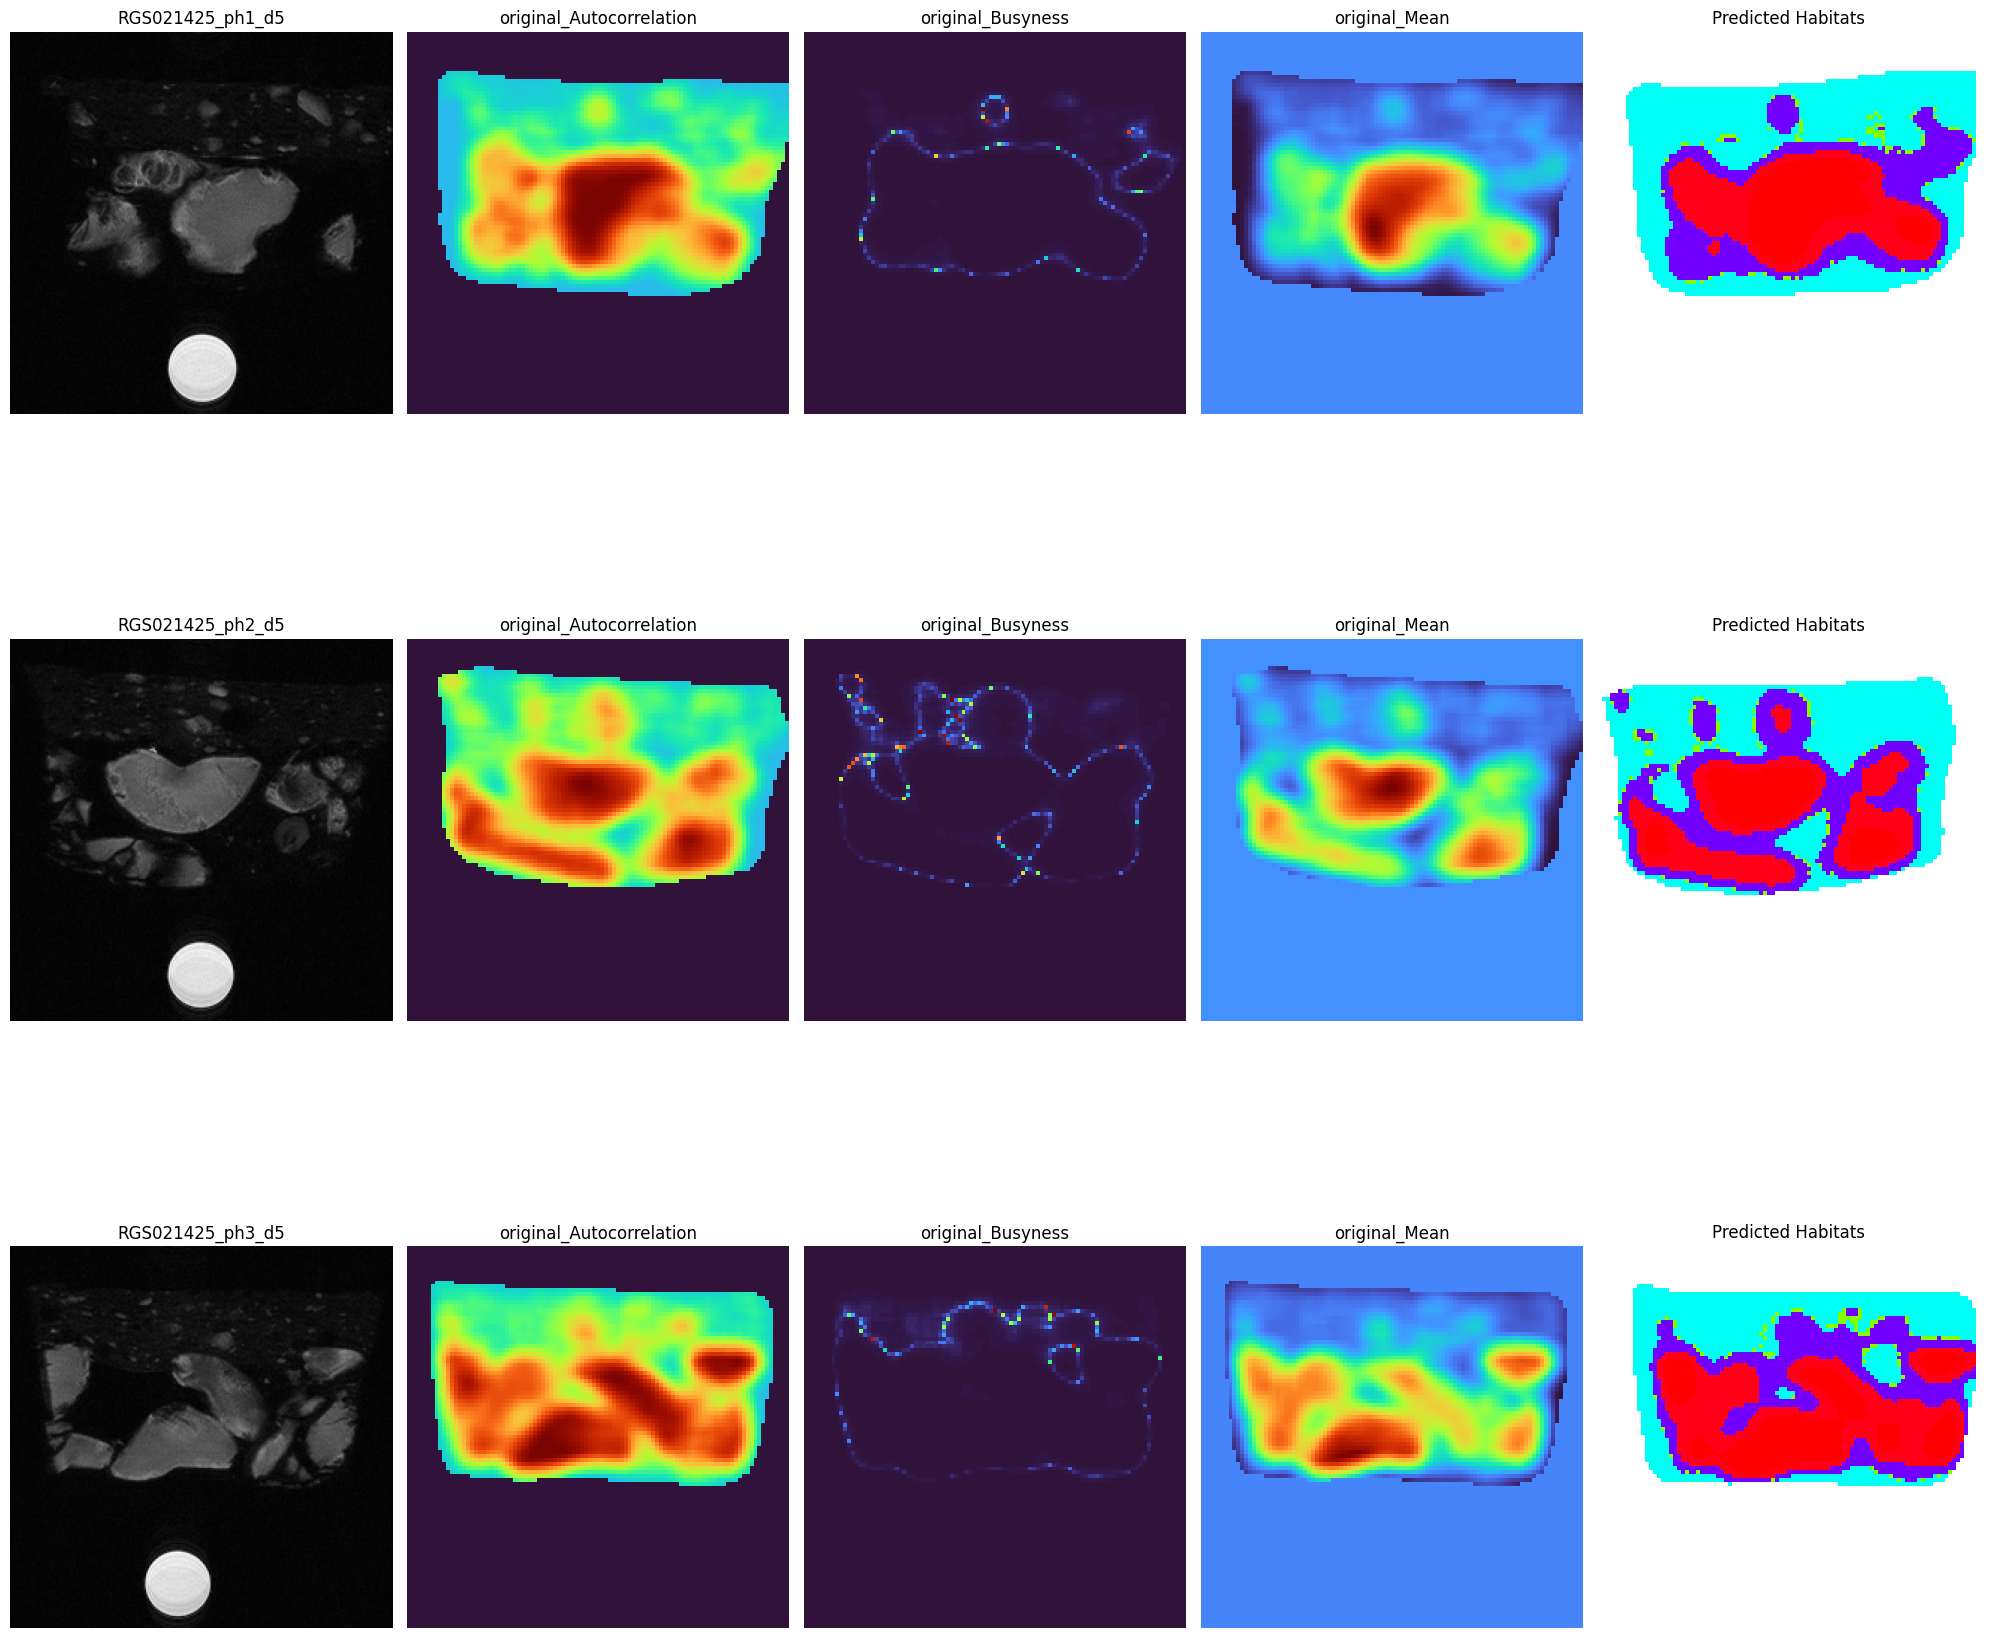

In [68]:
fig, ax = plt.subplots(len(test_data_dicts), len(features) + 2, figsize=(20,20))
sl = 15

for i, dd in enumerate(test_res_ddicts):
    img = sitk.ReadImage(dd['metadata']['image_path'])
    img_arr = sitk.GetArrayFromImage(img)

    img_maps = sitk.ReadImage(dd['image'])
    maps_arr = sitk.GetArrayFromImage(img_maps)
    num_maps = len(dd['feature_names'])

    ax[i,0].imshow(img_arr[sl,:,:], cmap='gray')
    ax[i,0].set_title(dd['case_id'] + '_' + dd['metadata']['timepoint'])

    for k in range(num_maps):
        ax[i,k+1].imshow(maps_arr[sl,:,:,k], cmap='turbo')
        ax[i,k+1].set_title(dd['feature_names'][k])

    ax[i,num_maps+1].imshow(train_predictions[i][sl,:,:], cmap='hsv')
    ax[i,num_maps+1].set_title('Predicted Habitats')
    
for a in ax.flatten():
    a.axis('off')
plt.tight_layout()